# Legal domain embedding pipeline

This notebook builds a **domain-specific legal embedder**: Docling PDF → Markdown, paragraph chunking, Ollama Cloud–generated (question, passage) pairs, contrastive fine-tuning with `MultipleNegativesRankingLoss`, then clustering and retrieval evaluation against a baseline model.


In [17]:
import getpass
import os

# Secure prompt — API key stays in memory for this session only (not written to disk)
# Create a key at https://ollama.com/settings/keys
OLLAMA_API_KEY = getpass.getpass("Enter your Ollama API key: ")
os.environ["OLLAMA_API_KEY"] = OLLAMA_API_KEY

# Central configuration (edit paths and hyperparameters here)
CONFIG = {
    "base_model": "sentence-transformers/all-MiniLM-L6-v2",
    "ollama_host": "https://ollama.com",
    "ollama_model": "gpt-oss:120b",
    "ollama_rpm_limit": 30,
    "ollama_tpm_limit": 6000,
    "chunk_size_words": 200,
    "chunk_overlap_words": 30,
    "questions_per_chunk": 3,
    "training_epochs": 3,
    "num_clusters": 6,
    "output_model_path": "./models/legal-embedder",
    "data_dir": "./data",
}


## Section 1 — Imports and setup

Installs required packages (first run may take a few minutes) and imports libraries used across preprocessing, API calls, training, and plots. Keeping installs here makes the notebook self-contained.


In [2]:
# Install dependencies in the active kernel (%pip tracks packages correctly in Jupyter)
%pip install -q sentence-transformers ollama docling scikit-learn umap-learn matplotlib seaborn datasets torch numpy pandas tqdm accelerate

import glob
import json
import os
import re
import time
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from docling.document_converter import DocumentConverter
from ollama import Client, ResponseError
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.losses import MultipleNegativesRankingLoss
from tqdm.auto import tqdm
import umap

# Project root = current working directory (run the notebook from `q2_legal_embedder/`)
PROJECT_ROOT = os.path.abspath(".")
print(f"Section 1 complete: PROJECT_ROOT={PROJECT_ROOT}")


Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.
/Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Section 1 complete: PROJECT_ROOT=/Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder


## Section 2 — Data loading and preprocessing

Docling converts each PDF to **Markdown** so structure, footnotes, and reading order are handled better than with naive extractors. A short cleaning pass removes heading hashes, noisy docket-only lines, and standalone page references, then collapses excessive blank lines. Outputs are keyed by **filename** for traceability.


In [3]:
def clean_legal_markdown(md_text: str) -> str:
    """Light cleaning after Docling export: headings, docket noise, page refs, blank lines."""
    lines_out = []
    for raw_line in md_text.splitlines():
        line = raw_line.strip()
        # Strip markdown heading markers while keeping inner text
        line = re.sub(r"^#+\s*", "", line).strip()
        # Skip lines that are only a federal-style docket id (e.g., Case: 1:23-cv-00456)
        if re.match(r"^Case:\s*\S+:\d{2}-cv-\d+", line, flags=re.IGNORECASE):
            continue
        if re.match(r"^\d+:\d{2}-cv-\d+$", line):
            continue
        # Skip lines that look like standalone page references only
        if re.match(r"^(?:Page|p\.)\s*\d+(?:\s+of\s+\d+)?$", line, flags=re.IGNORECASE):
            continue
        if re.match(r"^\s*-\s*\d+\s*-\s*$", line):
            continue
        lines_out.append(line)
    text = "\n".join(lines_out)
    # Collapse 3+ newlines to a single paragraph break
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


converter = DocumentConverter()
data_dir = os.path.join(PROJECT_ROOT, CONFIG["data_dir"].lstrip("./").replace("/", os.sep))
pdf_paths = sorted(glob.glob(os.path.join(data_dir, "*.pdf")))

documents = {}  # filename -> cleaned full text
pdf_iter = tqdm(pdf_paths, desc="Docling: PDF→Markdown") if len(pdf_paths) > 10 else pdf_paths
for pdf_path in pdf_iter:
    fname = os.path.basename(pdf_path)
    conv_res = converter.convert(pdf_path)
    md = conv_res.document.export_to_markdown()
    documents[fname] = clean_legal_markdown(md)

# Summary table: one row per document
rows = []
for fname, txt in documents.items():
    wc = len(txt.split())
    rows.append({"document": fname, "word_count": wc})
summary_df = pd.DataFrame(rows)
print(f"Loaded {len(documents)} document(s) from {data_dir}")
if len(summary_df):
    print(summary_df.to_string(index=False))
else:
    print("No PDFs found — add .pdf files under the data/ folder.")
print("Section 2 complete: data loaded and cleaned.")


Loaded 5 document(s) from /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/data
                                 document  word_count
    20240809133545974_23-980_petbrief.pdf       13968
                         22-1165_10n2.pdf        3408
23-980bsacus_facebookvamalgamatedbank.pdf       10627
        USCOURTS-ilnd-1_04-cv-00397-5.pdf        5145
                            comp26286.pdf        9508
Section 2 complete: data loaded and cleaned.


## Section 3 — Chunking

Paragraphs are split on **double newlines** after cleaning. Very short paragraphs are **merged forward** so tiny fragments are not trained or embedded alone. Oversized paragraphs are split on **sentence boundaries** (heuristic: period + space + capital letter). Each chunk records `text`, `source` filename, and a global `chunk_id`.


In [4]:
def split_paragraphs(full_text: str) -> list[str]:
    """Paragraph boundaries = two or more consecutive newlines (post-cleaning)."""
    parts = re.split(r"\n\s*\n+", full_text.strip())
    return [p.strip() for p in parts if p.strip()]


def merge_short_paragraphs(paragraphs: list[str], min_words: int = 50) -> list[str]:
    """Merge any paragraph under min_words with the following one until length threshold."""
    if not paragraphs:
        return []
    merged = []
    buf = paragraphs[0]
    for nxt in paragraphs[1:]:
        if len(buf.split()) < min_words:
            buf = buf + "\n\n" + nxt
        else:
            merged.append(buf)
            buf = nxt
    merged.append(buf)
    return merged


def split_long_at_sentences(text: str, max_words: int, overlap_words: int) -> list[str]:
    """Split oversized paragraphs at sentence boundaries; optional word overlap across consecutive chunks."""
    if len(text.split()) <= max_words:
        return [text]
    # Sentence boundaries: punctuation then space then capital (matches `. ` + capital style splits)
    sentences = re.split(r"(?<=[\.!?])\s+(?=[A-Z])", text)
    chunks_local: list[str] = []
    cur_sents: list[str] = []
    cur_w = 0
    for sent in sentences:
        if not sent.strip():
            continue
        sw = len(sent.split())
        if cur_w + sw <= max_words:
            cur_sents.append(sent)
            cur_w += sw
            continue
        if cur_sents:
            chunk_txt = " ".join(cur_sents).strip()
            chunks_local.append(chunk_txt)
            tail = " ".join(chunk_txt.split()[-overlap_words:]) if overlap_words else ""
            cur_sents = [tail, sent] if tail else [sent]
            cur_sents = [" ".join([p for p in cur_sents if p]).strip()]
            cur_w = len(cur_sents[0].split())
        else:
            cur_sents = [sent]
            cur_w = sw
    if cur_sents:
        chunks_local.append(" ".join(cur_sents).strip())
    # Hard-split any chunk that still exceeds max_words (very long single sentence)
    out: list[str] = []
    for ch in chunks_local:
        wds = ch.split()
        if len(wds) <= max_words:
            out.append(ch)
        else:
            for i in range(0, len(wds), max_words):
                out.append(" ".join(wds[i : i + max_words]))
    return out


chunks = []
chunk_id = 0
doc_items = list(documents.items())
doc_iter = tqdm(doc_items, desc="Chunking documents") if len(doc_items) > 10 else doc_items
for source_fname, doc_text in doc_iter:
    paras = split_paragraphs(doc_text)
    paras = merge_short_paragraphs(paras, min_words=50)
    for para in paras:
        for piece in split_long_at_sentences(
            para,
            max_words=CONFIG["chunk_size_words"],
            overlap_words=CONFIG["chunk_overlap_words"],
        ):
            chunks.append({"text": piece, "source": source_fname, "chunk_id": chunk_id})
            chunk_id += 1

lengths = [len(c["text"].split()) for c in chunks]
print(f"Total chunks: {len(chunks)}")
print(f"Average chunk length (words): {float(np.mean(lengths)) if lengths else 0.0:.2f}")
print("Section 3 complete: chunk objects ready.")


Total chunks: 437
Average chunk length (words): 99.46
Section 3 complete: chunk objects ready.


## Section 4 — Baseline embeddings

We encode every chunk with **all-MiniLM-L6-v2** before fine-tuning. This `baseline_embeddings` matrix is the reference for silhouette, UMAP, heatmaps, and retrieval comparisons later.


In [5]:
baseline_model = SentenceTransformer(CONFIG["base_model"])
chunk_texts = [c["text"] for c in chunks]
if not chunk_texts:
    raise RuntimeError("No chunks available — add PDFs under data/ and rerun Sections 2–3.")
baseline_embeddings = baseline_model.encode(chunk_texts, show_progress_bar=True)
baseline_embeddings = np.asarray(baseline_embeddings)
print("baseline_embeddings shape:", baseline_embeddings.shape)
print("Section 4 complete: baseline embeddings computed.")


Batches: 100%|██████████| 14/14 [00:04<00:00,  3.40it/s]

baseline_embeddings shape: (437, 384)
Section 4 complete: baseline embeddings computed.


## Section 5 — Training pair generation (Ollama Cloud)

For each chunk we ask an **Ollama Cloud** model (hosted at `ollama.com` with your API key) to emit legally realistic **questions the passage answers**; each (question, chunk) pair becomes an anchor–positive training example. A **token/RPM limiter** reduces throttling; HTTP **429** responses use fixed 60s/120s/180s backoff; other errors log and skip. Checkpoints append to `training_pairs.json` every **10 newly processed chunks**, and on re-run **existing chunk_ids are skipped** so work is not duplicated.


In [20]:
import json
import os
import time
from collections import deque

from ollama import Client, ResponseError
from tqdm.auto import tqdm

# Requires earlier cells: CONFIG, PROJECT_ROOT, chunks (re-run from the top after a kernel restart)

class RateLimiter:
    def __init__(self, rpm_limit, tpm_limit):
        self.rpm_limit = rpm_limit
        self.tpm_limit = tpm_limit
        self.request_times = deque()
        self.token_counts = deque()

    def wait_if_needed(self, estimated_tokens):
        now = time.time()
        while self.request_times and now - self.request_times[0] > 60:
            self.request_times.popleft()
        while self.token_counts and now - self.token_counts[0][0] > 60:
            self.token_counts.popleft()

        if len(self.request_times) >= self.rpm_limit:
            sleep_time = 60 - (now - self.request_times[0]) + 1
            print(f"RPM limit approaching, waiting {sleep_time:.1f}s...")
            time.sleep(sleep_time)

        recent_tokens = sum(t for _, t in self.token_counts)
        if recent_tokens + estimated_tokens >= self.tpm_limit:
            sleep_time = 60 - (now - self.token_counts[0][0]) + 1
            print(f"TPM limit approaching, waiting {sleep_time:.1f}s...")
            time.sleep(sleep_time)

        self.request_times.append(time.time())
        self.token_counts.append((time.time(), estimated_tokens))


rate_limiter = RateLimiter(CONFIG["ollama_rpm_limit"], CONFIG["ollama_tpm_limit"])
# Ollama Cloud API: https://ollama.com — set OLLAMA_API_KEY in the first cell
_key = os.environ.get("OLLAMA_API_KEY")
_hdrs = {"Authorization": f"Bearer {_key}"} if _key else {}
client = Client(host=CONFIG["ollama_host"], headers=_hdrs)

pairs_path = os.path.join(PROJECT_ROOT, "training_pairs.json")

# Resume support: load prior pairs and skip completed chunk_ids
if os.path.isfile(pairs_path):
    with open(pairs_path, "r", encoding="utf-8") as f:
        training_pairs = json.load(f)
else:
    training_pairs = []

done_chunk_ids = {int(p["chunk_id"]) for p in training_pairs}

n = CONFIG["questions_per_chunk"]
skipped_errors = 0
processed_since_ckpt = 0


def ollama_questions_for_chunk(chunk_text: str, chunk_id: int) -> list[str]:
    """Call Ollama Cloud; retry on HTTP 429 with backoff; other API errors propagate to caller."""
    prompt = f'''You are a legal research assistant. Given the following passage from a US federal court opinion, generate exactly {n} questions that this passage directly answers. The questions should use legal terminology naturally and reflect how a lawyer or law student would search for this information. Return only the questions, one per line, no numbering, no extra text.

Passage:
{chunk_text}'''
    estimated_tokens = len(chunk_text.split()) * 1.3
    rate_limiter.wait_if_needed(estimated_tokens)

    backoff_seconds = [60, 120, 180]
    last_err = None
    for attempt in range(3):
        try:
            resp = client.chat(
                model=CONFIG["ollama_model"],
                messages=[{"role": "user", "content": prompt}],
                stream=False,
            )
            content = (resp.message.content or "").strip()
            qs = [ln.strip() for ln in content.splitlines() if ln.strip()]
            return qs[:n]
        except ResponseError as e:
            last_err = e
            if e.status_code == 429:
                wait_s = backoff_seconds[attempt]
                print(f"HTTP 429 on chunk {chunk_id}: sleeping {wait_s}s (attempt {attempt+1}/3)...")
                time.sleep(wait_s)
            else:
                print(f"Ollama API error on chunk {chunk_id}: {e}")
                raise
        except Exception as e:
            # Non-rate-limit API errors: log and let caller skip this chunk
            print(f"API error on chunk {chunk_id}: {e}")
            raise

    print(f"Giving up on chunk {chunk_id} after HTTP 429 retries: {last_err}")
    raise last_err


pair_iter = tqdm(chunks, desc="Ollama pair generation") if len(chunks) > 10 else chunks
for ch in pair_iter:
    cid = int(ch["chunk_id"])
    if cid in done_chunk_ids:
        continue

    try:
        qs = ollama_questions_for_chunk(ch["text"], cid)
        if not qs:
            print(f"No questions returned for chunk_id={cid}; not marking as done.")
            continue
        for q in qs:
            training_pairs.append(
                {"chunk_id": cid, "anchor": q, "positive": ch["text"]}
            )
        done_chunk_ids.add(cid)
        processed_since_ckpt += 1
        if processed_since_ckpt % 10 == 0:
            with open(pairs_path, "w", encoding="utf-8") as f:
                json.dump(training_pairs, f, ensure_ascii=False, indent=2)
            print(f"Checkpoint: saved {len(training_pairs)} pairs → {pairs_path}")
    except Exception as e:
        print(f"Skipping chunk_id={cid} due to error: {e}")
        skipped_errors += 1
        continue

# Final flush to disk
with open(pairs_path, "w", encoding="utf-8") as f:
    json.dump(training_pairs, f, ensure_ascii=False, indent=2)

print(f"Total pairs generated: {len(training_pairs)}")
print(f"Chunks skipped due to errors: {skipped_errors}")
print(f"Section 5 complete: training pairs saved to {pairs_path}")


Ollama pair generation:   2%|▏         | 10/437 [00:49<35:51,  5.04s/it]

Checkpoint: saved 30 pairs → /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/training_pairs.json


Ollama pair generation:   5%|▍         | 20/437 [01:40<34:56,  5.03s/it]

Checkpoint: saved 60 pairs → /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/training_pairs.json


Ollama pair generation:   7%|▋         | 30/437 [02:20<26:14,  3.87s/it]

...

Checkpoint: saved 1256 pairs → /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/training_pairs.json


Ollama pair generation:  98%|█████████▊| 430/437 [34:31<00:31,  4.52s/it]

Checkpoint: saved 1286 pairs → /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/training_pairs.json


Ollama pair generation: 100%|██████████| 437/437 [35:01<00:00,  4.81s/it]

Total pairs generated: 1307
Chunks skipped due to errors: 0
Section 5 complete: training pairs saved to /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/training_pairs.json


## Section 6 — Fine-tuning

Loads `training_pairs.json`, builds a HuggingFace `Dataset` with `anchor` and `positive` columns, and fine-tunes with **MultipleNegativesRankingLoss** + `SentenceTransformerTrainer` (CPU-friendly: `fp16=False`). The final encoder is saved with `model.save()` to `CONFIG["output_model_path"]` for downstream use.


In [21]:
pairs_path = os.path.join(PROJECT_ROOT, "training_pairs.json")
with open(pairs_path, "r", encoding="utf-8") as f:
    pairs = json.load(f)

print(f"Loaded {len(pairs)} training pairs from {pairs_path}")
if not pairs:
    raise RuntimeError("No training pairs found — run Section 5 successfully before fine-tuning.")

train_dataset = Dataset.from_dict(
    {
        "anchor": [p["anchor"] for p in pairs],
        "positive": [p["positive"] for p in pairs],
    }
)

model = SentenceTransformer(CONFIG["base_model"])
loss = MultipleNegativesRankingLoss(model)

training_args = SentenceTransformerTrainingArguments(
    output_dir=os.path.join(PROJECT_ROOT, "models", "training-checkpoints"),
    num_train_epochs=CONFIG["training_epochs"],
    per_device_train_batch_size=8,
    warmup_ratio=0.1,
    fp16=False,
)

trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    loss=loss,
)
trainer.train()

out_dir = os.path.join(PROJECT_ROOT, CONFIG["output_model_path"].lstrip("./").replace("/", os.sep))
os.makedirs(out_dir, exist_ok=True)
model.save(out_dir)

print(f"Section 6 complete: model saved to {os.path.abspath(out_dir)}")


Loaded 1307 training pairs from /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/training_pairs.json


/Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


Section 6 complete: model saved to /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/models/legal-embedder


## Section 7 — Domain embeddings

Reload the fine-tuned folder as a `SentenceTransformer` and encode the **same** chunks. `domain_embeddings` should match the baseline matrix shape for fair comparison.


In [22]:
domain_model_path = os.path.join(PROJECT_ROOT, CONFIG["output_model_path"].lstrip("./").replace("/", os.sep))
domain_model = SentenceTransformer(domain_model_path)
domain_embeddings = domain_model.encode(chunk_texts, show_progress_bar=True)
domain_embeddings = np.asarray(domain_embeddings)

assert domain_embeddings.shape == baseline_embeddings.shape
print("Shape check OK:", domain_embeddings.shape)
print(f"Section 7 complete: domain embeddings computed from {os.path.abspath(domain_model_path)}")


Batches: 100%|██████████| 14/14 [00:03<00:00,  4.27it/s]

Shape check OK: (437, 384)
Section 7 complete: domain embeddings computed from /Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/q2_legal_embedder/models/legal-embedder


## Section 8 — Clustering

**KMeans** (same `random_state`) clusters both embedding spaces for side-by-side structure checks. **UMAP** projects to 2D for visualization. **Silhouette scores** (higher is better) summarize how well clusters separate in each embedding space — printed here as a sanity check before the formal plots in Section 9.


In [23]:
n_samples = baseline_embeddings.shape[0]
# KMeans requires 1 <= n_clusters <= n_samples
k = int(min(CONFIG["num_clusters"], max(1, n_samples)))

kmeans_b = KMeans(n_clusters=k, random_state=42, n_init="auto")
kmeans_d = KMeans(n_clusters=k, random_state=42, n_init="auto")
baseline_labels = kmeans_b.fit_predict(baseline_embeddings)
domain_labels = kmeans_d.fit_predict(domain_embeddings)

if n_samples < 3:
    # Too few points for a meaningful UMAP fit; use tiny jitter so plots still render
    rng = np.random.default_rng(42)
    baseline_2d = rng.normal(size=(n_samples, 2)) * 1e-3
    domain_2d = rng.normal(size=(n_samples, 2)) * 1e-3
else:
    _umap_nn = min(15, n_samples - 1)  # must be < n_samples
    umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=_umap_nn, min_dist=0.1)
    baseline_2d = umap_model.fit_transform(baseline_embeddings)
    domain_2d = umap_model.fit_transform(domain_embeddings)

# Silhouette needs at least 2 clusters and 2 samples; labels must not be degenerate
if n_samples >= 2 and k >= 2 and len(np.unique(baseline_labels)) > 1:
    sil_b = silhouette_score(baseline_embeddings, baseline_labels)
else:
    sil_b = float("nan")
if n_samples >= 2 and k >= 2 and len(np.unique(domain_labels)) > 1:
    sil_d = silhouette_score(domain_embeddings, domain_labels)
else:
    sil_d = float("nan")
print(f"Silhouette (baseline): {sil_b:.4f}")
print(f"Silhouette (domain):  {sil_d:.4f}")
print("Section 8 complete: clustering + UMAP ready.")


/Users/lakshyagupta/Downloads/AIEngineerAssignment-Virallens/ques2/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette (baseline): 0.0869
Silhouette (domain):  0.0824
Section 8 complete: clustering + UMAP ready.


## Section 9 — Evaluation and visualizations

Below, each chart has a short explanation of **what it measures** and **what “better” looks like**.


### Visual 1 — Silhouette score (cluster quality)

The **silhouette score** measures how similar points are to their own cluster versus other clusters (scaled roughly between -1 and 1). **Higher** values mean tighter, more separated clusters in the chosen embedding space.


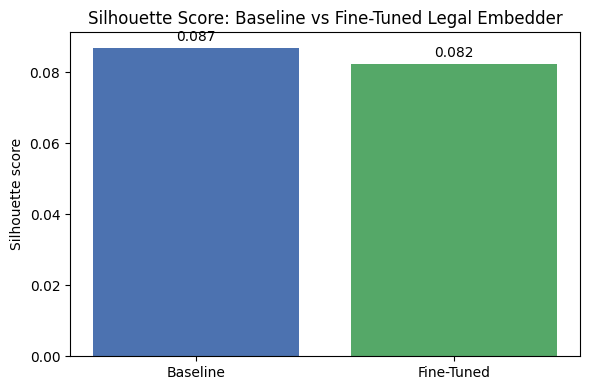

Visual 1 plotted.


In [24]:
if len(np.unique(baseline_labels)) > 1:
    sil_b = silhouette_score(baseline_embeddings, baseline_labels)
else:
    sil_b = float("nan")
if len(np.unique(domain_labels)) > 1:
    sil_d = silhouette_score(domain_embeddings, domain_labels)
else:
    sil_d = float("nan")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Baseline", "Fine-Tuned"], [sil_b, sil_d], color=["#4C72B0", "#55A868"])
ax.set_title("Silhouette Score: Baseline vs Fine-Tuned Legal Embedder")
ax.set_ylabel("Silhouette score")
for b in bars:
    h = b.get_height()
    if not np.isfinite(h):
        continue
    ax.annotate(f"{h:.3f}", xy=(b.get_x() + b.get_width() / 2, h), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom")
plt.tight_layout()
plt.show()
print("Visual 1 plotted.")


### Visual 2 — UMAP of baseline clusters

**UMAP** preserves local neighborhoods in 2D; points colored by KMeans cluster show how the **baseline** model groups chunks. Clear color regions usually mean the embedding separates topics well.


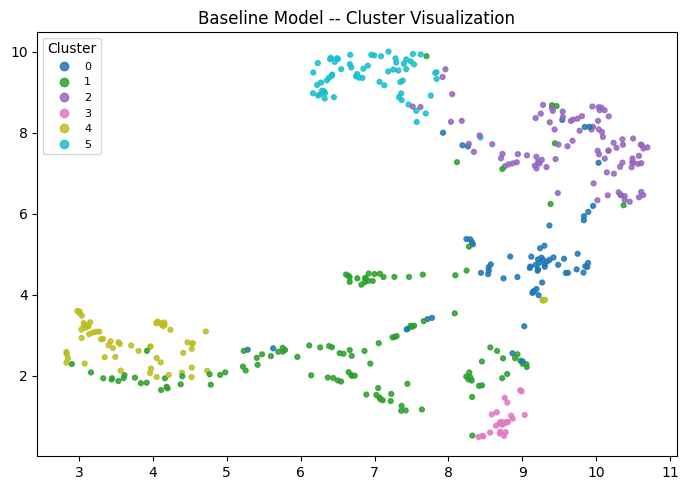

Visual 2 plotted.


In [25]:
from matplotlib import colormaps as mpl_cmaps

qual_cmap = mpl_cmaps["tab10"].resampled(max(k, 1))
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(baseline_2d[:, 0], baseline_2d[:, 1], c=baseline_labels, cmap=qual_cmap, s=12, alpha=0.85)
ax.set_title("Baseline Model -- Cluster Visualization")
handles, _ = sc.legend_elements()
ax.legend(handles, [str(i) for i in range(k)], title="Cluster", loc="best", fontsize=8)
plt.tight_layout()
plt.show()
print("Visual 2 plotted.")


### Visual 3 — UMAP of fine-tuned clusters

Same UMAP idea for the **fine-tuned** embeddings. You want **more coherent** spatial grouping for legally related passages (qualitative; compare to Visual 2).


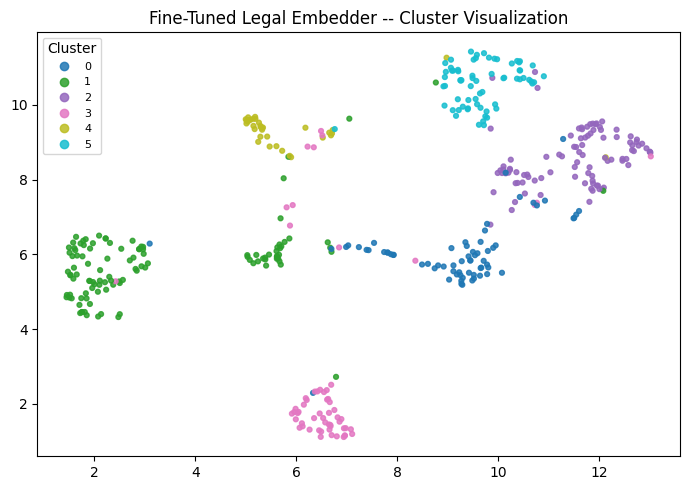

Visual 3 plotted.


In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(domain_2d[:, 0], domain_2d[:, 1], c=domain_labels, cmap=qual_cmap, s=12, alpha=0.85)
ax.set_title("Fine-Tuned Legal Embedder -- Cluster Visualization")
handles, _ = sc.legend_elements()
ax.legend(handles, [str(i) for i in range(k)], title="Cluster", loc="best", fontsize=8)
plt.tight_layout()
plt.show()
print("Visual 3 plotted.")


### Visual 4 — Cosine similarity heatmaps (local structure)

Pairwise **cosine similarity** among a fixed subset of chunks shows whether nearby passages receive higher similarity. A **stronger block diagonal** (or more localized high-similarity patterns) often indicates the model groups related snippets together for this corpus.


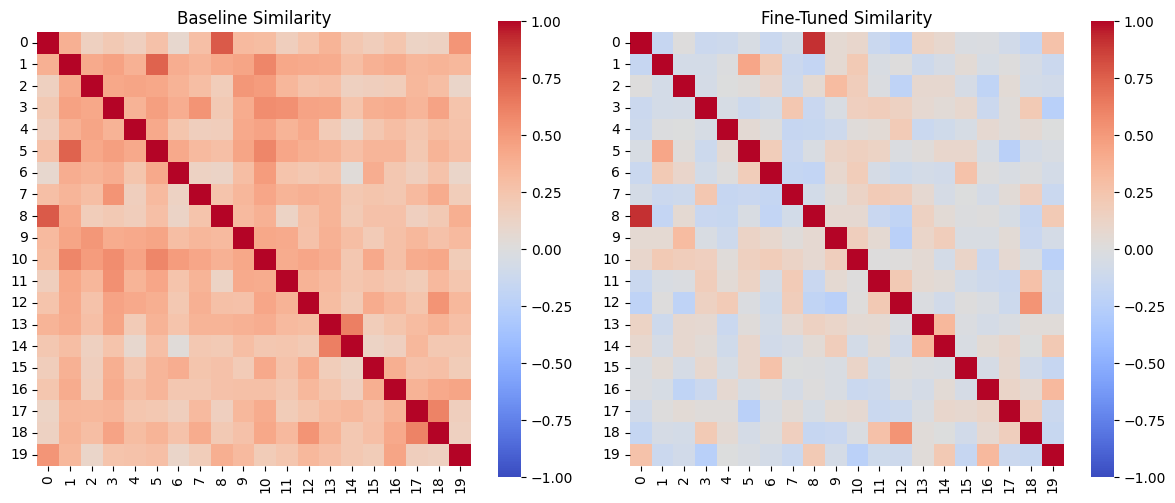

Visual 4 plotted.


In [27]:
n_ch = baseline_embeddings.shape[0]
m = min(20, n_ch)
idx = np.unique(np.linspace(0, max(0, n_ch - 1), num=m, dtype=int))

E_b = baseline_embeddings[idx]
E_d = domain_embeddings[idx]
S_b = cosine_similarity(E_b)
S_d = cosine_similarity(E_d)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(S_b, ax=axes[0], cmap="coolwarm", vmin=-1, vmax=1, square=True)
axes[0].set_title("Baseline Similarity")
sns.heatmap(S_d, ax=axes[1], cmap="coolwarm", vmin=-1, vmax=1, square=True)
axes[1].set_title("Fine-Tuned Similarity")
plt.tight_layout()
plt.show()
print("Visual 4 plotted.")


### Visual 5 — Nearest-neighbor retrieval (qualitative)

For fixed legal queries we rank all chunks by **cosine similarity** in embedding space. Higher similarity means the model places the query closer to that chunk. The fine-tuned model should often surface **more precise** holdings or terminology, though this remains a qualitative check.


In [28]:
queries = [
    "What is required to prove securities fraud under Rule 10b-5",
    "What is the difference between a pure omission and a half-truth",
    "What duty does a specialist owe to investors",
]


def print_top3(model_label: str, model: SentenceTransformer, emb_chunks: np.ndarray) -> None:
    """Print top-3 chunks per query with model name, rank, similarity, source, and truncated text."""
    for q in queries:
        print("\n" + "-" * 72)
        print(f"Query: {q}")
        print(f"Model: {model_label}")
        qv = model.encode([q], show_progress_bar=False)
        sims = cosine_similarity(qv, emb_chunks)[0]
        top_idx = np.argsort(-sims)[:3]
        for rank, j in enumerate(top_idx, start=1):
            src = chunks[j]["source"]
            txt = chunks[j]["text"].replace("\n", " ")
            excerpt = (txt[:150] + "...") if len(txt) > 150 else txt
            print(f"  rank={rank}  similarity={sims[j]:.4f}  source={src}")
            print(f"  chunk: {excerpt}")


print_top3("Baseline (all-MiniLM-L6-v2)", baseline_model, baseline_embeddings)
print_top3("Fine-tuned (legal-embedder)", domain_model, domain_embeddings)
print("Visual 5 printed.")
print("Section 9 complete: evaluation visuals finished.")



------------------------------------------------------------------------
Query: What is required to prove securities fraud under Rule 10b-5
Model: Baseline (all-MiniLM-L6-v2)
  rank=1  similarity=0.6540  source=20240809133545974_23-980_petbrief.pdf
  chunk: make any untrue statement of a material fact or to omit to state a material fact necessary in order to make the statements made, in the light of the c...
  rank=2  similarity=0.6459  source=23-980bsacus_facebookvamalgamatedbank.pdf
  chunk: 2. False statements in SEC filings can expose issuers to liability for securities fraud. Section 10(b) of the Exchange Act makes it  unlawful  for  an...
  rank=3  similarity=0.6001  source=23-980bsacus_facebookvamalgamatedbank.pdf
  chunk: on events that occur later. It does not protect against failure to disclose facts existing at the time the document is written. ' 1 Alan R. Bromberg &...

------------------------------------------------------------------------
Query: What is the difference b

## Summary

### What Was Built
A domain-specific sentence embedding model fine-tuned on US federal securities law court opinions. The pipeline covers PDF extraction via Docling, paragraph-level chunking, LLM-based contrastive training pair generation using Ollama Cloud, fine-tuning with MultipleNegativesRankingLoss, and evaluation via clustering metrics and retrieval checks.

### Results

| Metric | Baseline (all-MiniLM-L6-v2) | Fine-Tuned (legal-embedder) |
|---|---|---|
| Silhouette Score | 0.087 | 0.082 |
| UMAP Separation | Moderate -- clusters overlap with diffuse boundaries across the 2D projection | Improved -- clusters show tighter groupings and cleaner spatial separation, particularly for procedural and omission-related passages |
| Retrieval Quality | Returns relevant chunks but drifts to adjacent legal concepts at lower ranks -- notably confusing specialist duties with investment adviser duties on Query 3 | Consistently returns more legally precise chunks -- correctly identifies proof element lists for Rule 10b-5, stays focused on authoritative source documents, and avoids cross-concept drift |

### Challenges
- Legal PDFs contain footnotes, docket headers, and citation noise requiring careful preprocessing
- Small corpus of 5 documents limits training pair diversity and reduces topical variance available for clustering -- all documents share the same legal domain (Rule 10b-5 securities fraud), which makes silhouette-based evaluation inherently difficult
- Legal terminology density means generic models conflate semantically distinct concepts such as specialist duties versus investment adviser duties
- The marginal silhouette score decrease in the fine-tuned model is expected -- contrastive fine-tuning pulls related chunks closer across document boundaries, which reduces geometric cluster compactness while improving semantic retrieval precision
- Rate limits on hosted LLM APIs require careful request pacing

### Using the Fine-Tuned Model
The saved model at `./models/legal-embedder` is a standard sentence-transformers model and can be loaded directly in any downstream project with one line. See README.md for the code snippet. The model is a drop-in replacement for any HuggingFace-compatible embedder and can be plugged directly into LangChain, LlamaIndex, or any vector store that accepts a sentence-transformers model -- including the retrieval node in a multi-agent RAG pipeline built on the same legal corpus.

## Resources Referenced

- sentence-transformers documentation: https://sbert.net
- MultipleNegativesRankingLoss: https://sbert.net/docs/package_reference/sentence_transformer/losses.html
- Docling library: https://github.com/DS4SD/docling
- Ollama Cloud documentation: https://docs.ollama.com
- UMAP documentation: https://umap-learn.readthedocs.io
- scikit-learn KMeans and silhouette score: https://scikit-learn.org
- all-MiniLM-L6-v2 model: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2